In [14]:
import yaml
import numpy as np 
from pytorch_lightning import Trainer
import importlib
from tqdm import tqdm




In [2]:
path = 'config/attentional_cue/attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor.yaml'
config = yaml.load(open(path, 'r'), Loader=yaml.FullLoader)

In [3]:
!nvidia-smi

Wed Jul  5 17:31:25 2023       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 460.67       Driver Version: 460.67       CUDA Version: 11.2     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Quadro RTX 6000     On   | 00000000:3B:00.0 Off |                  Off |
| 33%   36C    P8    14W / 260W |     13MiB / 24220MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
                                                                               
+-------

In [4]:
# config['n_jobs'] = 0

batch_size = 64
config['data']['loader']['batch_size'] = batch_size
config['data']['loader']['num_workers'] = 10
config['data']['audio']['rep_kwargs']['rep_on_gpu'] = False
# config['corpora_name'] = 'TIMIT'
# config['data']['corpus']['clean_targets'] = False
# config['data']['corpus']['root'] = '/om2/user/imgriff/datasets/timit/attn_task_dataframes/timit_attn_stim_for_model_all_targets.pdpkl'

ckpt_path =  "/om2/user/imgriff/projects/Auditory-Attention/attn_cue_models/attn_cue_jsin_multi_distractor_w_audioset_bs_64_lr_1e-4/checkpoints/epoch=0-step=70000.ckpt"

In [21]:
config['noise_kwargs']

{'low_snr': -10, 'high_snr': 10}

In [6]:
from src import attn_tracking_lightning
importlib.reload(attn_tracking_lightning)

AttentionalaTrackingModule = attn_tracking_lightning.AttentionalTrackingModule

model = AttentionalaTrackingModule.load_from_checkpoint(checkpoint_path=ckpt_path, config=config, strict=False)

ln_first
center_crop=False
binaural=False
using IIR cochleagram


In [7]:
data_loader = model.val_dataloader()

In [8]:
import torch

In [9]:
device = torch.device('cuda:0')

In [10]:
model = model.eval().cuda()
outputs = []
labels = []

n_examples = 2000

n_batches = n_examples // batch_size
with torch.no_grad():
    for ix, batch in tqdm(enumerate(data_loader), total=n_batches):
        mixture, cue, label = batch
        batch_out = model(cue.cuda(), mixture.cuda())
        outputs.append(batch_out)
        labels.append(label)
        if ix == n_batches:
            break

100%|██████████| 31/31 [02:14<00:00,  4.33s/it]


In [12]:
outputs = torch.cat(outputs, dim=0).cpu()
softmax_outputs = torch.softmax(outputs, dim=-1)
labels = torch.cat(labels, dim=0).cpu()

TypeError: cat() received an invalid combination of arguments - got (Tensor, dim=int), but expected one of:
 * (tuple of Tensors tensors, int dim, *, Tensor out)
 * (tuple of Tensors tensors, name dim, *, Tensor out)


## Plot histogram of softmax outputs  


Want to look at distribution of correct outputs vs off-target outputs 


In [15]:
%matplotlib inline

import matplotlib.pyplot as plt
import seaborn as sns

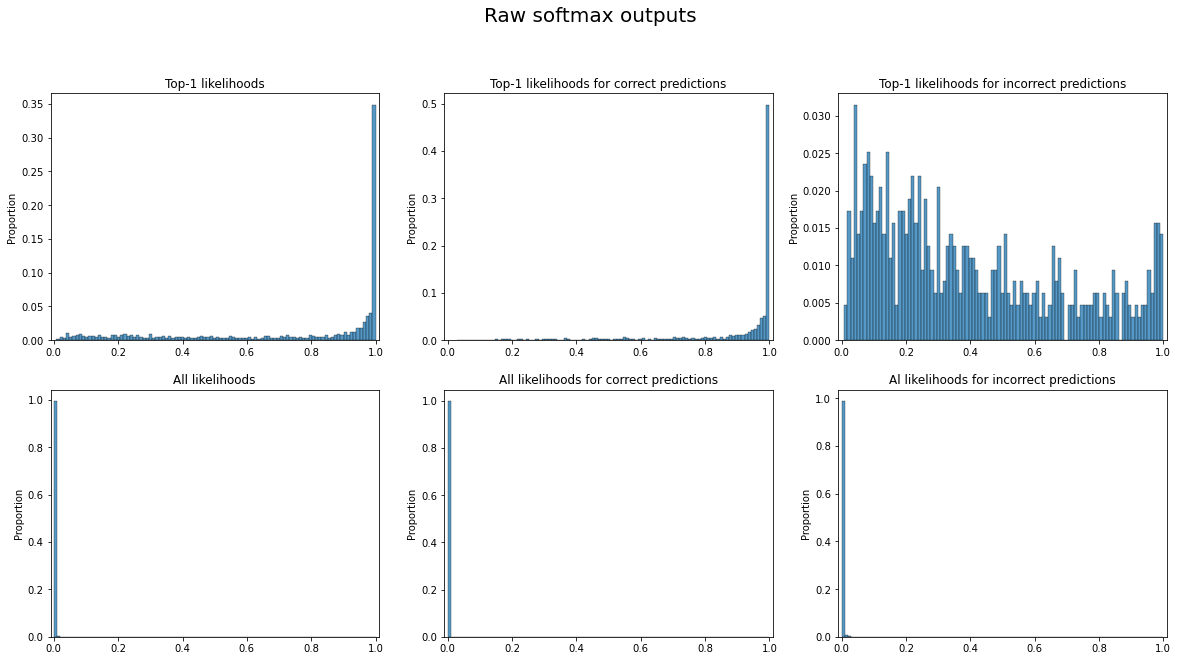

In [16]:

model_likelihoods, class_pred = softmax_outputs.max(-1)

model_likelihoods = model_likelihoods.numpy()

hits = (class_pred == labels)

correct_likelihoods = model_likelihoods[hits]
miss_likelihoods = model_likelihoods[~hits]

fig, axs = plt.subplots(2,3, figsize=(20,10))

sns.histplot(model_likelihoods, ax=axs[0,0], bins=100, stat='proportion');
axs[0, 0].set_title('Top-1 likelihoods');

# axs[1].hist(correct_likelihoods, bins=100);
sns.histplot(correct_likelihoods, ax=axs[0,1], bins=100, stat='proportion');
axs[0, 1].set_title('Top-1 likelihoods for correct predictions');

sns.histplot(miss_likelihoods, ax=axs[0,2], bins=100, stat='proportion');
axs[0, 2].set_title('Top-1 likelihoods for incorrect predictions');

# All outputs, not just top 1 
sns.histplot(softmax_outputs.flatten(), ax=axs[1,0], bins=100, stat='proportion');
axs[1, 0].set_title('All likelihoods');

# axs[1].hist(correct_likelihoods, bins=100);
sns.histplot(softmax_outputs[hits, : ].flatten(), ax=axs[1,1], bins=100, stat='proportion')
axs[1, 1].set_title('All likelihoods for correct predictions');

sns.histplot(softmax_outputs[~hits, : ].flatten(), ax=axs[1,2], bins=100, stat='proportion')
axs[1, 2].set_title('Al likelihoods for incorrect predictions');

plt.suptitle('Raw softmax outputs', y=1, fontsize=20);
plt.setp(axs, xlim=(-0.01, 1.01));


[-0.01, 1.01, -0.01, 1.01, -0.01, 1.01, -0.01, 1.01, -0.01, 1.01, -0.01, 1.01]

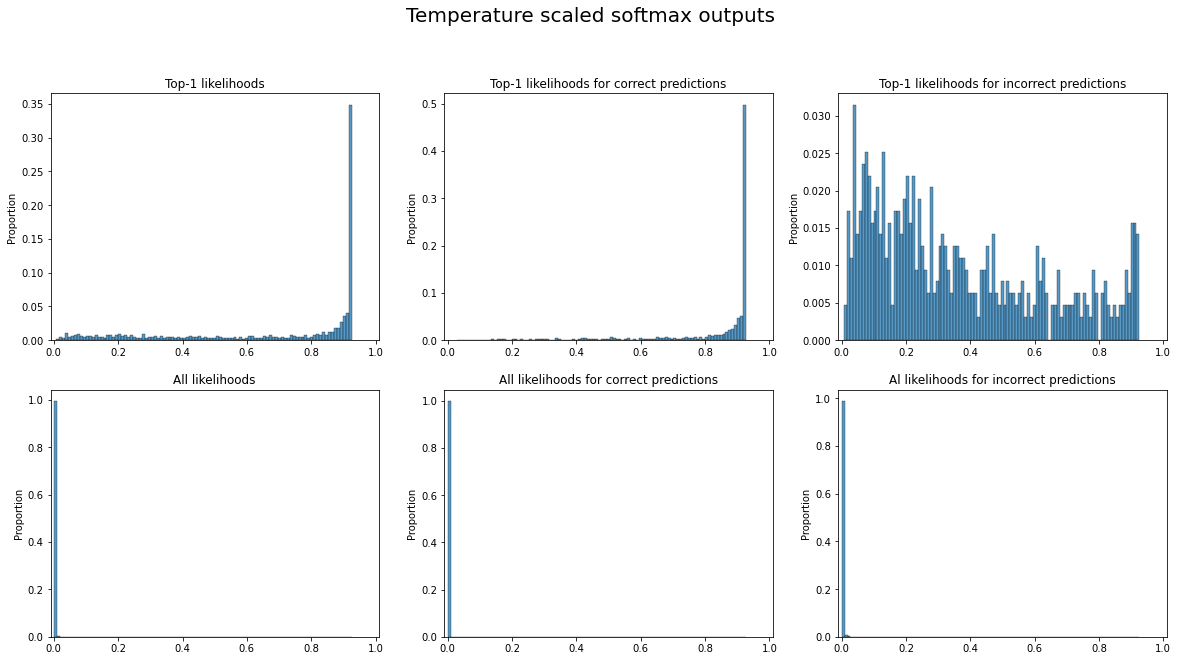

In [17]:
## Try again with scaling 

scaled_softmax = softmax_outputs / 1.08 # was good Temp parameter 


model_scaled_predictions, class_pred = scaled_softmax.max(-1)

model_scaled_predictions = model_scaled_predictions.numpy()

hits = (class_pred == labels)

correct_scaled_likelihoods = model_scaled_predictions[hits]
miss_scaled_likelihoods = model_scaled_predictions[~hits]


fig, axs = plt.subplots(2,3, figsize=(20,10))

sns.histplot(model_scaled_predictions, ax=axs[0,0], bins=100, stat='proportion');
axs[0, 0].set_title('Top-1 likelihoods');

# axs[1].hist(correct_scaled_likelihoods, bins=100);
sns.histplot(correct_scaled_likelihoods, ax=axs[0,1], bins=100, stat='proportion');
axs[0, 1].set_title('Top-1 likelihoods for correct predictions');

sns.histplot(miss_scaled_likelihoods, ax=axs[0,2], bins=100, stat='proportion');
axs[0, 2].set_title('Top-1 likelihoods for incorrect predictions');

# All outputs, not just top 1 
sns.histplot(scaled_softmax.flatten(), ax=axs[1,0], bins=100, stat='proportion');
axs[1, 0].set_title('All likelihoods');

# axs[1].hist(correct_scaled_likelihoods, bins=100);
sns.histplot(scaled_softmax[hits, : ].flatten(), ax=axs[1,1], bins=100, stat='proportion');
axs[1, 1].set_title('All likelihoods for correct predictions');

sns.histplot(scaled_softmax[~hits, : ].flatten(), ax=axs[1,2], bins=100, stat='proportion');
axs[1, 2].set_title('Al likelihoods for incorrect predictions');

plt.suptitle('Temperature scaled softmax outputs', y=1, fontsize=20);

plt.setp(axs, xlim=(-0.01, 1.01))


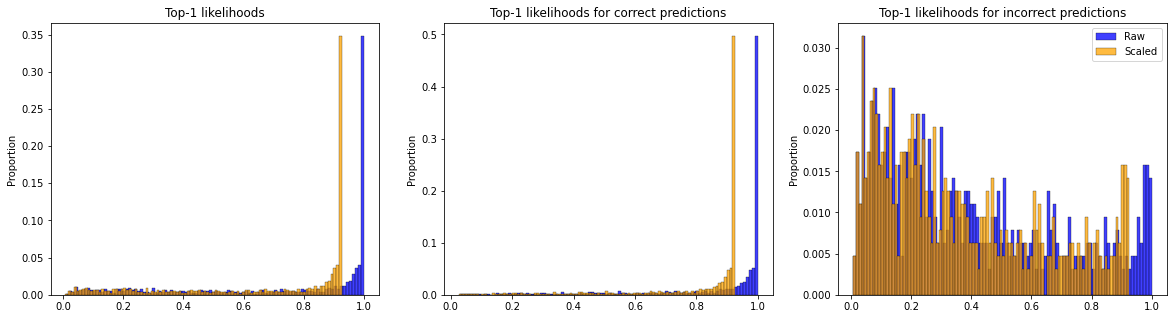

In [18]:
## Plot scaled on top of unscaled 

fig, axs = plt.subplots(1,3, figsize=(20,5))


sns.histplot(model_likelihoods, ax=axs[0], bins=100, stat='proportion', color='blue');
sns.histplot(model_scaled_predictions, ax=axs[0], bins=100, stat='proportion', color='orange');
axs[ 0].set_title('Top-1 likelihoods');

# axs[1].hist(correct_scaled_likelihoods, bins=100);
sns.histplot(correct_likelihoods, ax=axs[1], bins=100, stat='proportion', color='blue');
sns.histplot(correct_scaled_likelihoods, ax=axs[1], bins=100, stat='proportion', color='orange');
axs[ 1].set_title('Top-1 likelihoods for correct predictions');

sns.histplot(miss_likelihoods, ax=axs[2], bins=100, stat='proportion', color='blue', label='Raw');
sns.histplot(miss_scaled_likelihoods, ax=axs[2], bins=100, stat='proportion', color='orange', label='Scaled');
axs[ 2].set_title('Top-1 likelihoods for incorrect predictions');

plt.legend()

## Plot softmax outputs for different scene configurations

In [22]:
config['noise_kwargs']

{'low_snr': -10, 'high_snr': 10}

In [32]:
# setup model and run  using high SNRS 

# config['n_jobs'] = 0

batch_size = 64
config['data']['loader']['batch_size'] = batch_size
config['data']['loader']['num_workers'] = 10
config['data']['audio']['rep_kwargs']['rep_on_gpu'] = False
# set to virtual inf  SNR
config['noise_kwargs']['low_snr'] = "clean"
config['noise_kwargs']['high_snr'] = "clean"

ckpt_path =  "/om2/user/imgriff/projects/Auditory-Attention/attn_cue_models/attn_cue_jsin_multi_distractor_w_audioset_bs_64_lr_1e-4/checkpoints/epoch=0-step=70000.ckpt"

from src import attn_tracking_lightning
importlib.reload(attn_tracking_lightning)

AttentionalaTrackingModule = attn_tracking_lightning.AttentionalTrackingModule

model = AttentionalaTrackingModule.load_from_checkpoint(checkpoint_path=ckpt_path, config=config, strict=False)

data_loader = model.val_dataloader()

model = model.eval().cuda()

high_snr_outputs = []
high_snr_labels = []

n_examples = 2000

n_batches = n_examples // batch_size
with torch.no_grad():
    for ix, batch in tqdm(enumerate(data_loader), total=n_batches):
        mixture, cue, label = batch
        batch_out = model(cue.cuda(), mixture.cuda())
        high_snr_outputs.append(batch_out)
        high_snr_labels.append(label)
        if ix == n_batches:
            break
high_snr_outputs = torch.cat(high_snr_outputs, dim=0).cpu()
softmax_high_snr_outputs = torch.softmax(high_snr_outputs, dim=-1)
high_snr_labels = torch.cat(high_snr_labels, dim=0).cpu()


ln_first
center_crop=False
binaural=False
using IIR cochleagram


100%|██████████| 31/31 [02:10<00:00,  4.21s/it]


In [24]:
# high_snr_outputs = torch.cat(high_snr_outputs, dim=0).cpu()
# softmax_high_snr_outputs = torch.softmax(high_snr_outputs, dim=-1)
# high_snr_labels = torch.cat(high_snr_labels, dim=0).cpu()

In [27]:
### Low SNR 

# setup model and run  using high SNRS 

# config['n_jobs'] = 0

batch_size = 64
config['data']['loader']['batch_size'] = batch_size
config['data']['loader']['num_workers'] = 10
config['data']['audio']['rep_kwargs']['rep_on_gpu'] = False
# set to virtual inf  SNR
config['noise_kwargs']['low_snr'] = -10
config['noise_kwargs']['low_snr'] = -10

ckpt_path =  "/om2/user/imgriff/projects/Auditory-Attention/attn_cue_models/attn_cue_jsin_multi_distractor_w_audioset_bs_64_lr_1e-4/checkpoints/epoch=0-step=70000.ckpt"

from src import attn_tracking_lightning
importlib.reload(attn_tracking_lightning)

AttentionalaTrackingModule = attn_tracking_lightning.AttentionalTrackingModule

model = AttentionalaTrackingModule.load_from_checkpoint(checkpoint_path=ckpt_path, config=config, strict=False)

data_loader = model.val_dataloader()

model = model.eval().cuda()

low_snr_outputs = []
low_snr_labels = []

n_examples = 2000

n_batches = n_examples // batch_size
with torch.no_grad():
    for ix, batch in tqdm(enumerate(data_loader), total=n_batches):
        mixture, cue, label = batch
        batch_out = model(cue.cuda(), mixture.cuda())
        low_snr_outputs.append(batch_out)
        low_snr_labels.append(label)
        if ix == n_batches:
            break

low_snr_outputs = torch.cat(low_snr_outputs, dim=0).cpu()
softmax_low_snr_outputs = torch.softmax(low_snr_outputs, dim=-1)
low_snr_labels = torch.cat(low_snr_labels, dim=0).cpu()

ln_first
center_crop=False
binaural=False
using IIR cochleagram


100%|██████████| 31/31 [02:13<00:00,  4.30s/it]


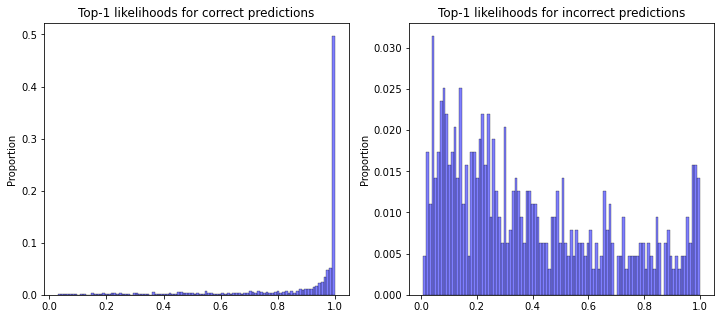

In [42]:
## Plot High SNR 

# normal 
model_likelihoods, class_pred = softmax_outputs.max(-1)
model_likelihoods = model_likelihoods.numpy()
hits = (class_pred == labels)
correct_likelihoods = model_likelihoods[hits]
miss_likelihoods = model_likelihoods[~hits]

# high SNR 
h_snr_model_likelihoods, h_snr_class_pred = softmax_high_snr_outputs.max(-1)
h_snr_model_likelihoods = h_snr_model_likelihoods.numpy()
h_snr_hits = (h_snr_class_pred == high_snr_labels)
h_snr_correct_likelihoods = h_snr_model_likelihoods[h_snr_hits]
h_snr_miss_likelihoods = h_snr_model_likelihoods[~h_snr_hits]

# low SNR 
l_snr_model_likelihoods, l_snr_class_pred = softmax_low_snr_outputs.max(-1)
l_snr_model_likelihoods = l_snr_model_likelihoods.numpy()
l_snr_hits = (l_snr_class_pred == low_snr_labels)
l_snr_correct_likelihoods = l_snr_model_likelihoods[l_snr_hits]
l_snr_miss_likelihoods = l_snr_model_likelihoods[~l_snr_hits]

fig, ax = plt.subplots(1,2, figsize=(12,5))

axs = {1:ax[0], 2:ax[1]}

# sns.histplot(model_likelihoods, ax=axs[0], bins=100, stat='proportion', color='blue', alpha=0.5);
# sns.histplot(h_snr_model_likelihoods, ax=axs[0], bins=100, stat='proportion', color='green', alpha=0.5);
# sns.histplot(l_snr_model_likelihoods, ax=axs[0], bins=100, stat='proportion', color='red', alpha=0.5);
# axs[ 0].set_title('Top-1 likelihoods');

# axs[1].hist(correct_scaled_likelihoods, bins=100);
# sns.histplot(h_snr_correct_likelihoods, ax=axs[1], bins=100, stat='proportion', color='green', alpha=0.5);
# sns.histplot(l_snr_correct_likelihoods, ax=axs[1], bins=100, stat='proportion', color='red', alpha=0.5);
sns.histplot(correct_likelihoods, ax=axs[1], bins=100, stat='proportion', color='blue', alpha=0.5);

axs[ 1].set_title('Top-1 likelihoods for correct predictions');

# sns.histplot(h_snr_miss_likelihoods, ax=axs[2], bins=100, stat='proportion', color='green', label='Inf SNR', alpha=0.5);
# sns.histplot(l_snr_miss_likelihoods, ax=axs[2], bins=100, stat='proportion', color='red', label='-10dB SNR', alpha=0.5);
sns.histplot(miss_likelihoods, ax=axs[2], bins=100, stat='proportion', color='blue', label='-10dB to 10dB SNR', alpha=0.5);

axs[ 2].set_title('Top-1 likelihoods for incorrect predictions');

# plt.legend()

## Implement a few versions of calibration error measures 

In [ ]:

def ECE_metric(softmax_outputs, labels, n_bins=15):
    '''Guo et al. 2017  estimated calibration error'''
    bin_boundaries = torch.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]
    confidences, predictions = softmax_outputs.max(-1)
    accuracies = predictions.eq(labels)
    bin_confidences = []
    bin_accuracies = []
    ece = torch.zeros(1)
    rms_ece = torch.zeros(1)
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        in_bin = confidences.gt(bin_lower.item()) * confidences.le(bin_upper.item())
        prop_in_bin = in_bin.float().mean()
        avg_confidence_in_bin = 0
        accuracy_in_bin = 0
        if prop_in_bin.item() > 0:
            accuracy_in_bin = accuracies[in_bin].float().mean()
            avg_confidence_in_bin = confidences[in_bin].mean()
            # Guo et al. 2017  estimated calibration error
            ece += torch.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin
            # AugMix error
            rms_ece += torch.pow(avg_confidence_in_bin - accuracy_in_bin, 2) * prop_in_bin

        bin_confidences.append(avg_confidence_in_bin)
        bin_accuracies.append(accuracy_in_bin)
    
    rms_ece = torch.sqrt(rms_ece)

    return ece, rms_ece, bin_confidences, bin_accuracies


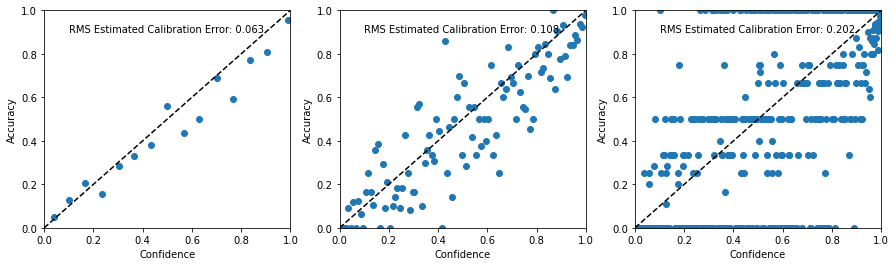

In [ ]:
# plotting the softmax outputs

n_bins = [15, 100, 500]

fig, ax = plt.subplots(1, len(n_bins), figsize=(15, 4))
for ix, n in enumerate(n_bins):
    ece, rms_ece, batch_confidence, batch_accuracy = ECE_metric(softmax_outputs, labels, n_bins=n)
    ax[ix].scatter(batch_confidence, batch_accuracy)
    ax[ix].plot([0, 1], [0, 1], linestyle='dashed', color='k')
    # ax[ix].annotate(f'Estimated Calibration Error: {ece.item():.3f}', (0.1, 0.9))
    ax[ix].annotate(f'RMS Estimated Calibration Error: {rms_ece.item():.3f}', (0.1, 0.9))
    ax[ix].set_xlabel('Confidence')
    ax[ix].set_ylabel('Accuracy')
    ax[ix].set_ylim(0, 1)
    ax[ix].set_xlim(0, 1)

## Dynamic binning method as in Hendrycks et al., 2020 (AugMix paper)

Similar to original, but M bins (and bin boundaries) is selected dynamically to ensure even number of samples per bin when computing calibration error, and RMS calibration error is reported rather than Expected (mean) calibration error.    
Note, Hendrycks et al., uses 100 samples per bin. 


In all cases, calibration error depennds on choice of binning, yielding distinct temperature parameters per configuration  

In [ ]:

def n_per_bin_calibration_error(softmax_outputs, labels, n_per_bin=100):
    bin_boundaries = np.histogram_bin_edges(softmax_outputs, bins=softmax_outputs.shape[0]//n_per_bin, range=None, weights=None)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]
    confidences, predictions = softmax_outputs.max(-1)
    accuracies = predictions.eq(labels)
    bin_confidences = []
    bin_accuracies = []
    ece = torch.zeros(1)
    rms_ece = torch.zeros(1)
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        in_bin = confidences.gt(bin_lower.item()) * confidences.le(bin_upper.item())
        prop_in_bin = in_bin.float().mean()
        avg_confidence_in_bin = 0
        accuracy_in_bin = 0
        if prop_in_bin.item() > 0:
            accuracy_in_bin = accuracies[in_bin].float().mean()
            avg_confidence_in_bin = confidences[in_bin].mean()
            # Guo et al. 2017  estimated calibration error
            ece += torch.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin
            # AugMix RMS error
            rms_ece += torch.pow(avg_confidence_in_bin - accuracy_in_bin, 2) * prop_in_bin

        bin_confidences.append(avg_confidence_in_bin)
        bin_accuracies.append(accuracy_in_bin)
    
    rms_ece = torch.sqrt(rms_ece)

    return ece, rms_ece, bin_confidences, bin_accuracies


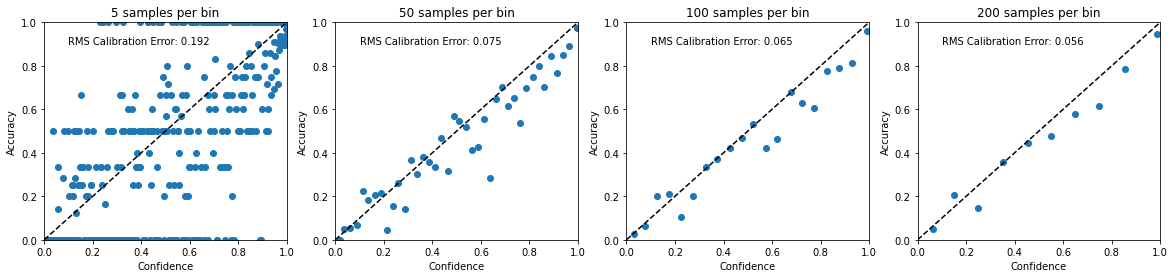

In [ ]:
# plotting the softmax outputs

n_per_bin = [5, 50, 100, 200]

fig, ax = plt.subplots(1, len(n_per_bin), figsize=(20, 4))
for ix, n in enumerate(n_per_bin):
    ece, rms_ece, batch_confidence, batch_accuracy = n_per_bin_calibration_error(softmax_outputs, labels, n_per_bin=n)
    ax[ix].scatter(batch_confidence, batch_accuracy)
    ax[ix].plot([0, 1], [0, 1], linestyle='dashed', color='k')
    # ax[ix].annotate(f'Estimated Calibration Error: {ece.item():.3f}', (0.1, 0.9))
    ax[ix].annotate(f'RMS Calibration Error: {rms_ece.item():.3f}', (0.1, 0.9))
    ax[ix].set_xlabel('Confidence')
    ax[ix].set_ylabel('Accuracy')
    ax[ix].set_title(f'{n} samples per bin')
    ax[ix].set_ylim(0, 1)
    ax[ix].set_xlim(0, 1)

## Try with different types of signal difficulties 



In [ ]:
config['data']['corpus']['n_talkers'] = 1 # 1 talker
config['data']['noise_kwargs'] = {'low_snr': 10, 'high_snr': 10}, # High SNR

del config['data']['corpus']['noise_kwargs']
model = AttentionalaTrackingModule.load_from_checkpoint(checkpoint_path=ckpt_path, config=config, strict=False)
data_loader = model.val_dataloader()

ln_first
center_crop=False
binaural=False
using IIR cochleagram


In [ ]:
model = model.eval().cuda()
outputs = []
labels = []

n_examples = 100

n_batches = n_examples // batch_size
with torch.no_grad():
    for ix, batch in tqdm(enumerate(data_loader), total=n_batches):
        mixture, cue, label = batch
        batch_out = model(cue.cuda(), mixture.cuda())
        outputs.append(batch_out)
        labels.append(label)
        if ix == n_batches:
            break

  0%|          | 0/3 [00:00<?, ?it/s]

In [ ]:
label_array = torch.zeros_like(outputs).scatter_(1, labels.unsqueeze(-1), 1)

In [ ]:
# confidence judgment 1
conf1 = softmax_outputs.max(axis=1)[0] - softmax_outputs.mean(axis=1)

In [ ]:
uniform_dist = np.ones(outputs.shape) / outputs.shape[-1]
uniary_dist = np.zeros(outputs.shape[1])
uniary_dist[0] = 1
uniform_row = np.ones(uniary_dist.shape) / uniary_dist.shape[-1]

In [ ]:
# confidence judgment 2
kl_loss1 = torch.nn.KLDivLoss(reduction='none', log_target=False)(torch.log(torch.Tensor(softmax_outputs)), torch.Tensor(uniform_dist)).sum(axis=1)
kl_loss2 = torch.nn.KLDivLoss(reduction='none', log_target=False)(torch.log(torch.Tensor(uniform_dist)), torch.Tensor(softmax_outputs)).sum(axis=1)
balanced_KL = (kl_loss1 + kl_loss2) / 2
entropy = torch.distributions.Categorical(probs=torch.Tensor(uniform_dist)).entropy()
conf2 = entropy + balanced_KL

min_conf2 = torch.nn.KLDivLoss(reduction='none')(torch.log(torch.Tensor(uniform_row)), torch.Tensor(uniform_row)).sum(axis=0)
min_conf2 += torch.nn.KLDivLoss(reduction='none')(torch.log(torch.Tensor(uniform_row)), torch.Tensor(uniform_row)).sum(axis=0)
min_conf2 = min_conf2 / 2
min_conf2 += torch.distributions.Categorical(probs=torch.Tensor(uniform_row)).entropy()

max_conf2 = torch.nn.KLDivLoss(reduction='none')(torch.log(torch.Tensor(uniform_row)), torch.Tensor(uniary_dist)).sum(axis=0)
max_conf2 += torch.nn.KLDivLoss(reduction='none')(torch.log(torch.Tensor(uniary_dist)), torch.Tensor(uniform_row)).sum(axis=0)
max_conf2 = max_conf2 / 2
max_conf2 += torch.distributions.Categorical(probs=torch.Tensor(uniform_row)).entropy()

In [ ]:
def cross_entropy(p, q, axis=1):
    """Hand compute the cross entropy loss, where labels and outputs are arrays of the same shape
    and softmax has already been applied to p."""
    kl_loss = torch.nn.KLDivLoss(reduction='none', log_target=False)(torch.log(p), q).sum(axis = axis)
    entropy = torch.distributions.Categorical(probs=q).entropy()
    return entropy + kl_loss

In [ ]:
# confidence judgment 3
conf_3 = cross_entropy(torch.Tensor(softmax_outputs), torch.Tensor(uniform_dist), 1)

min_conf3 = cross_entropy(torch.Tensor(uniform_row), torch.Tensor(uniform_row), 0)

max_conf3 = cross_entropy(torch.Tensor(uniary_dist), torch.Tensor(uniform_row), 0)

In [ ]:
correct = model_guesses.numpy() == labels.numpy()
correct.mean()

0.8686567164179104

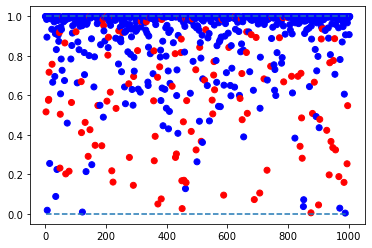

In [ ]:
# confidence histograms

colors = ['b' if c else 'r' for c in correct]
plt.scatter(np.arange(len(conf1)), conf1, c=colors)
plt.hlines(0, 1, 1000, linestyles='dashed')
plt.hlines(1, 1, 1000, linestyles='dashed')


/om2/user/imgriff/conda_envs/torch_11_cuda_11_pitch/lib/python3.9/site-packages/matplotlib/axes/_base.py:2475: UserWarning: Warning: converting a masked element to nan.
  xys = np.asarray(xys)


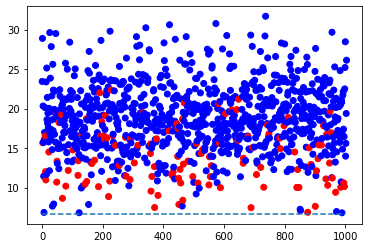

In [ ]:
plt.scatter(np.arange(len(conf2)), conf2, c=colors)
plt.hlines(min_conf2, 1, 1000, linestyles='dashed')
plt.hlines(max_conf2, 1, 1000, linestyles='dashed')

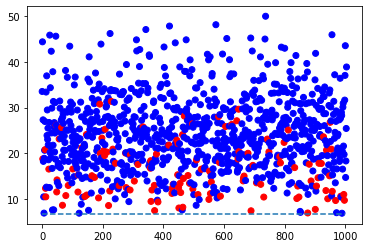

In [ ]:
plt.scatter(np.arange(len(conf_3)), conf_3, c=colors)
plt.hlines(min_conf3, 1, 1000, linestyles='dashed')
plt.hlines(max_conf3, 1, 1000, linestyles='dashed')

In [ ]:
def ECELoss(outputs, labels, n_bins=15):
    bin_boundaries = torch.linspace(0, 1, n_bins + 1)
    bin_lowers = bin_boundaries[:-1]
    bin_uppers = bin_boundaries[1:]
    confidences, predictions = torch.max(outputs, 1)
    accuracies = predictions.eq(labels)
    bin_confidences = []
    bin_accuracies = []

    ece = torch.zeros(1)
    for bin_lower, bin_upper in zip(bin_lowers, bin_uppers):
        in_bin = confidences.gt(bin_lower.item()) * confidences.le(bin_upper.item())
        prop_in_bin = in_bin.float().mean()
        avg_confidence_in_bin = 0
        accuracy_in_bin = 0
        if prop_in_bin.item() > 0:
            accuracy_in_bin = accuracies[in_bin].float().mean()
            avg_confidence_in_bin = confidences[in_bin].mean()
            ece += torch.abs(avg_confidence_in_bin - accuracy_in_bin) * prop_in_bin
        bin_confidences.append(avg_confidence_in_bin)
        bin_accuracies.append(accuracy_in_bin)
        

    return ece, bin_confidences, bin_accuracies

(0.0, 1.0)

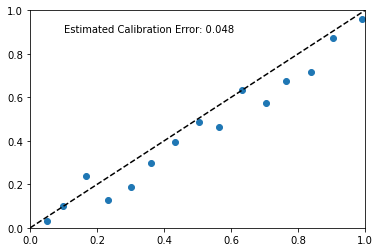

In [ ]:
# plotting the softmax outputs
estimated_calibration_error, batch_confidence, batch_accuracy = ECELoss(softmax_outputs, labels)
plt.scatter(batch_confidence, batch_accuracy)
plt.plot([0, 1], [0, 1], linestyle='dashed', color='k')
plt.annotate(f'Estimated Calibration Error: {estimated_calibration_error.item():.3f}', (0.1, 0.9))
plt.ylim(0, 1)
plt.xlim(0, 1)

In [ ]:
temp = torch.load('/om2/user/rphess/Auditory-Attention/confidenceScores/pilot/parameters/temperatureparemeters.pt').cpu()
temp_out = outputs / temp
temp_softmax = torch.softmax(temp_out, dim=1)

(0.0, 1.0)

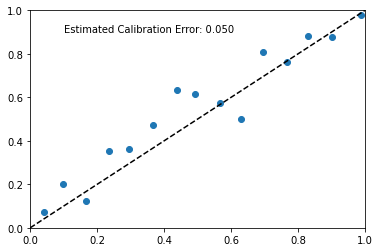

In [ ]:
# plotting the softmax outputs
estimated_calibration_error, batch_confidence, batch_accuracy = ECELoss(temp_softmax.detach(), labels)
plt.scatter(batch_confidence, batch_accuracy)
plt.plot([0, 1], [0, 1], linestyle='dashed', color='k')
plt.annotate(f'Estimated Calibration Error: {estimated_calibration_error.item():.3f}', (0.1, 0.9))
plt.ylim(0, 1)
plt.xlim(0, 1)

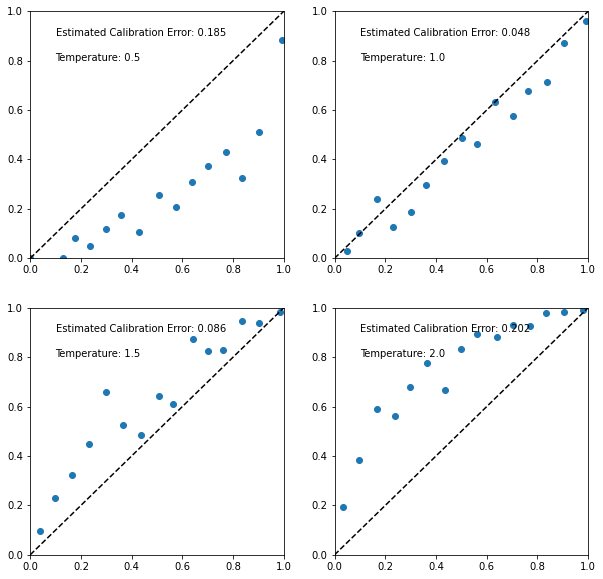

In [ ]:
### test range of temperatures from .5 to 2
temperatures = np.arange(.5, 2.5, .5)
fig, ax = plt.subplots(2, 2, figsize=(10, 10))
for ix, temp in enumerate(temperatures):
    temp_out = outputs / temp
    temp_softmax = torch.softmax(temp_out, dim=1)
    ece, conf, acc = ECELoss(temp_softmax.detach(), labels)
    ax[ix // 2, ix % 2].scatter(conf, acc)
    ax[ix // 2, ix % 2].plot([0, 1], [0, 1], linestyle='dashed', color='k')
    ax[ix // 2, ix % 2].annotate(f'Estimated Calibration Error: {ece.item():.3f}', (0.1, 0.9))
    ax[ix // 2, ix % 2].annotate(f'Temperature: {temp}', (0.1, 0.8))
    ax[ix // 2, ix % 2].set_ylim(0, 1)
    ax[ix // 2, ix % 2].set_xlim(0, 1)

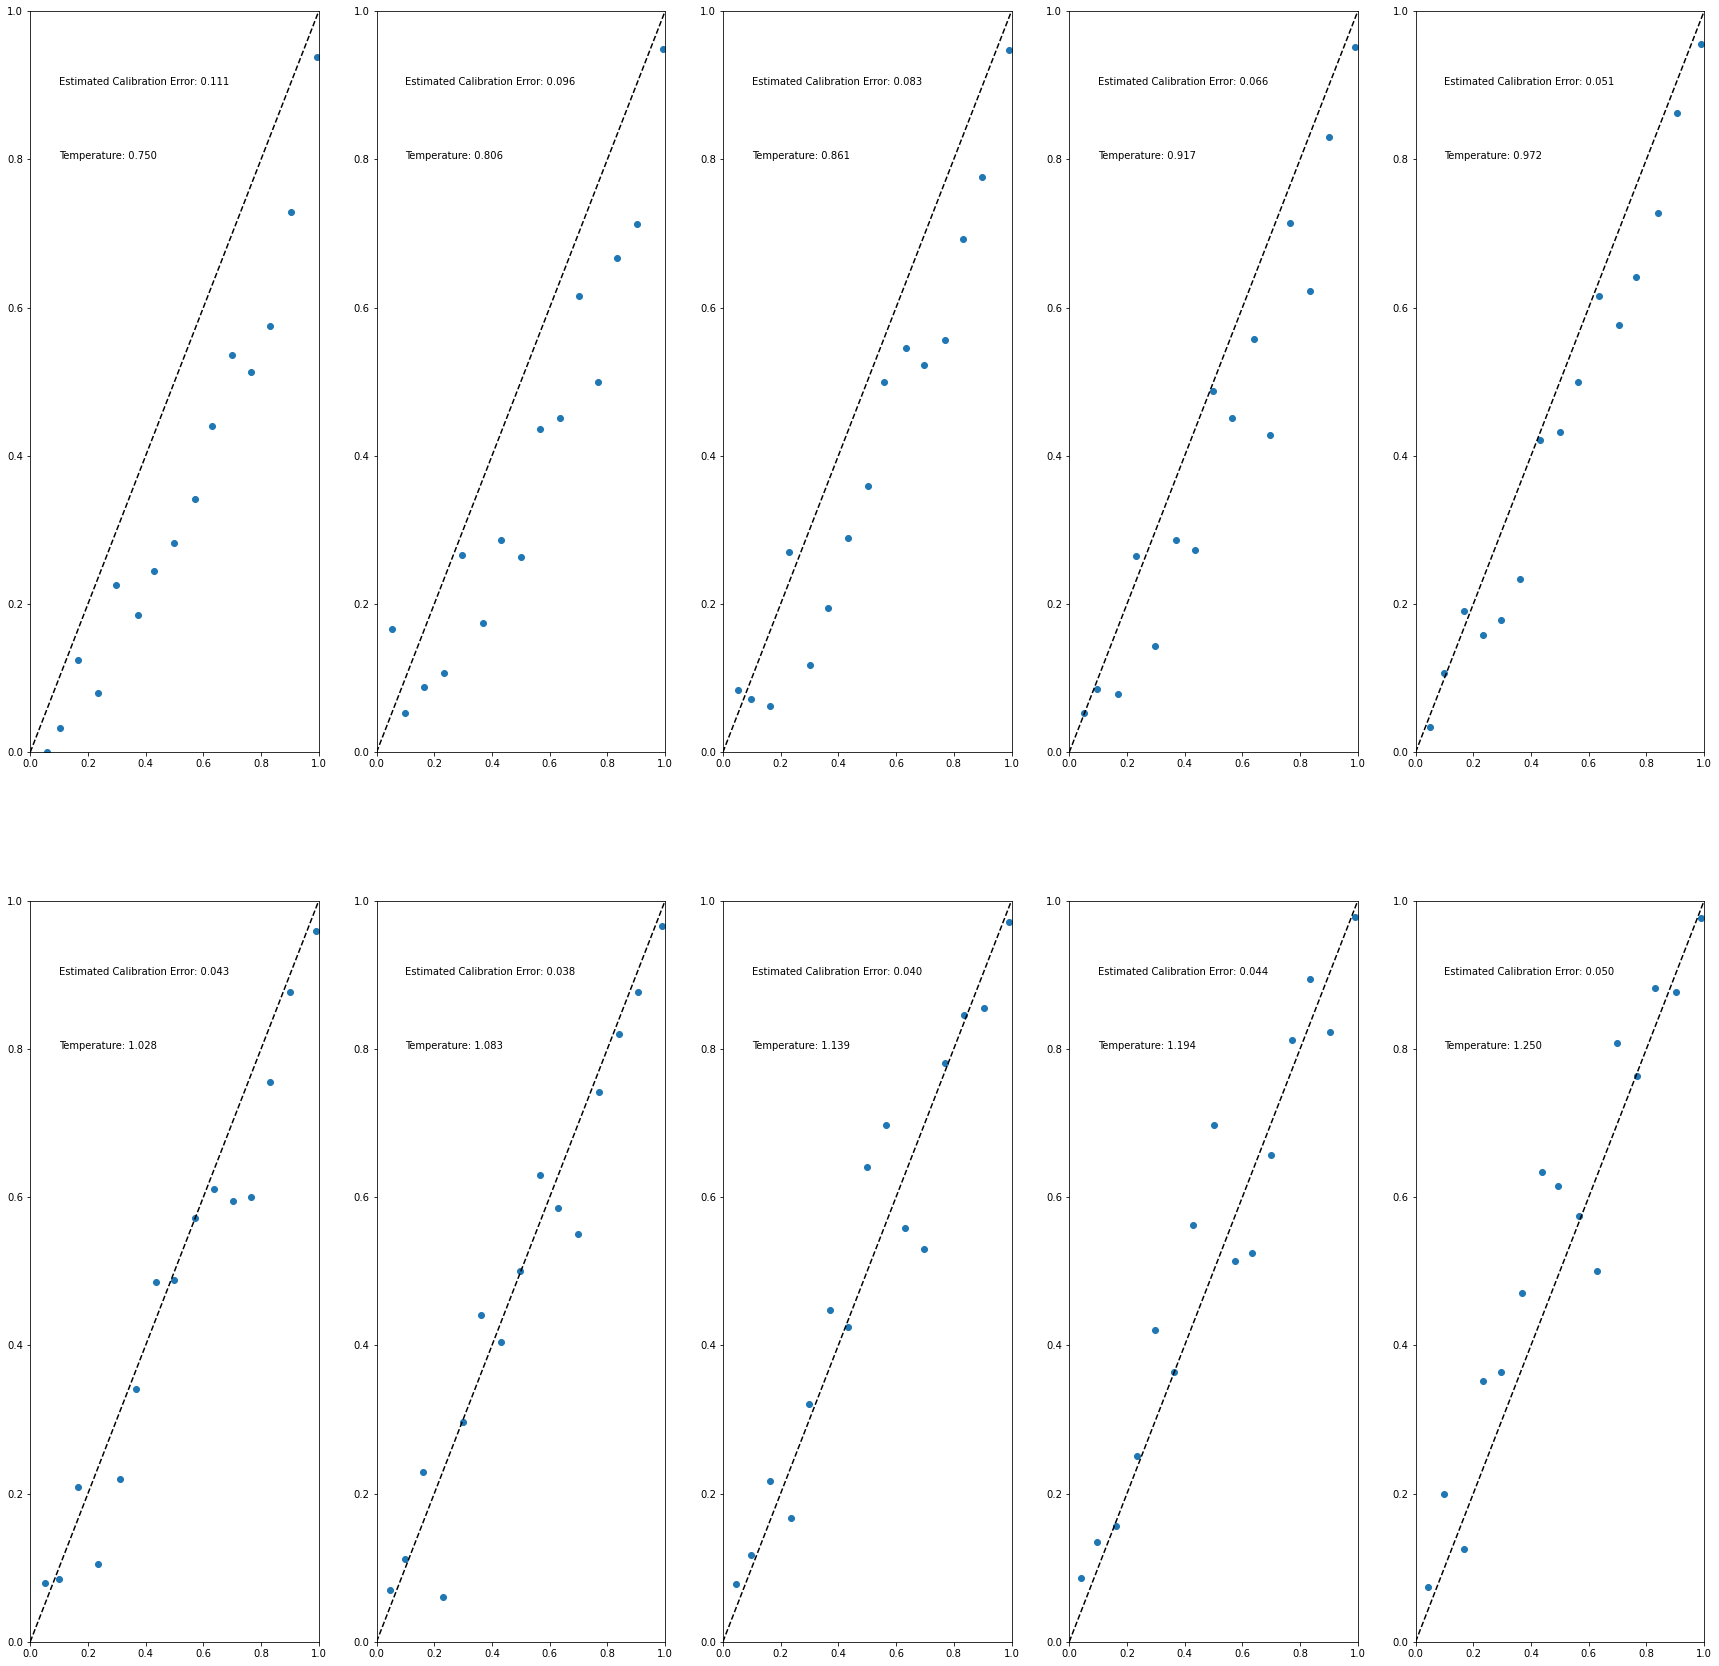

In [ ]:
### test range of temperatures from 1.25 to 1.75
temperatures = np.linspace(.75, 1.25, 10)
fig, ax = plt.subplots(2, 5, figsize=(30, 30))
ax = ax.flatten()
for ix, temp in enumerate(temperatures):
    temp_out = outputs / temp
    temp_softmax = torch.softmax(temp_out, dim=1)
    ece, conf, acc = ECELoss(temp_softmax.detach(), labels)
    ax[ix].scatter(conf, acc)
    ax[ix].plot([0, 1], [0, 1], linestyle='dashed', color='k')
    ax[ix].annotate(f'Estimated Calibration Error: {ece.item():.3f}', (0.1, 0.9))
    ax[ix].annotate(f'Temperature: {temp:.3f}', (0.1, 0.8))
    ax[ix].set_ylim(0, 1)
    ax[ix].set_xlim(0, 1)
### best param is 1.083

In [ ]:
class TemperatureScalingCalibrationModule(torch.nn.Module):

    def __init__(self, model_path, config):
        super().__init__()
        self.model_path = model_path
        self.model = AttentionalaTrackingModule.load_from_checkpoint(checkpoint_path=model_path, config=config)
        self.temperature = torch.nn.Parameter(torch.ones(1))

    def forward(self, cue, mixture=None):
        outputs = self.forward_logits(cue, mixture)
        scores = torch.nn.functional.softmax(outputs, dim=-1)
        return scores

    def forward_logits(self, cue, mixture=None):
        logits = self.model(cue, mixture)
        return logits / self.temperature

    def fit(self, train_loader, n_epochs=100, lr=1e-3):
        self.freeze_base_model()
        criterion = torch.nn.CrossEntropyLoss()
        optimizer = torch.optim.SGD(self.parameters(), lr=lr)

        global_loss = float('inf')
        n_tolerance_steps = 100
        for epoch in range(n_epochs):
            for ix, batch in enumerate(train_loader):
                mixture, cue, label = batch
                self.zero_grad()
                predict = self.forward_logits(cue.cuda(), mixture.cuda())
                loss = criterion(predict, label.cuda())
                loss.backward()
                optimizer.step()

                if abs(loss.item() - global_loss) > 1e-3 and loss.item() < global_loss:
                    global_loss = loss.item()
                    n_tolerance_steps = 100
                elif abs(loss.item() - global_loss) < 1e-3:
                    n_tolerance_steps -= 1

                if n_tolerance_steps == 0:
                    return self
                if ix % 100 == 0:
                    print(f'Epoch {epoch} step: {ix} loss: {loss.item()}')
        return self
                

    def freeze_base_model(self):
        self.model.eval()
        for para in self.model.parameters():
            para.requires_grad = False

        return self



In [ ]:
calibration_module = TemperatureScalingCalibrationModule(ckpt_path, config).cuda()
calibration_module.fit(train_loader, n_epochs=5, lr=1e-1)
print('# of parameters:', sum(p.numel() for p in calibration_module.parameters() if p.requires_grad))

ln_first
Epoch 0 step: 0 loss: 0.0731530636548996
Epoch 0 step: 100 loss: 1.4407224655151367
Epoch 0 step: 200 loss: 3.941483974456787
Epoch 0 step: 300 loss: 4.3122878074646
Epoch 0 step: 400 loss: 3.632981777191162


In [ ]:
learned_t = torch.load('/om2/user/rphess/Auditory-Attention/confidenceScores/pilot/parameters/temperatureparemeters.pt')

In [ ]:
learned_t

Parameter containing:
tensor([1.0190], device='cuda:0', requires_grad=True)

In [ ]:
calibration_module = TemperatureScalingCalibrationModule(ckpt_path, config).cuda()
calibration_module.temperature = torch.nn.Parameter(learned_t)

ln_first


In [ ]:
train_loader = model.val_dataloader()

AttributeError: 'TemperatureScalingCalibrationModule' object has no attribute 'val_dataloader'

In [ ]:
model = calibration_module.eval().cuda()
outputs = []
labels = []
with torch.no_grad():
    for ix, batch in tqdm(enumerate(train_loader), total=200):
        mixture, cue, label = batch
        batch_out = model(cue.cuda(), mixture.cuda())
        outputs.append(batch_out)
        labels.append(label)
        if ix == 200:
            break

100%|██████████| 200/200 [00:51<00:00,  3.86it/s]


In [ ]:
outputs = torch.cat(outputs, dim=0).cpu()
labels = torch.cat(labels, dim=0).cpu()

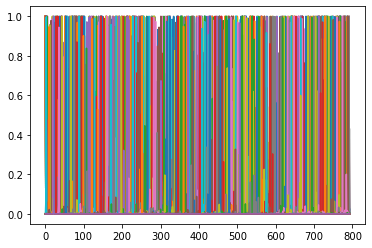

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.plot(outputs.detach().numpy().T);

In [ ]:
model_guesses = outputs.argmax(-1)
model_guesses

tensor([577, 714, 715,  ..., 513, 402,  21])

(0.0, 1.0)

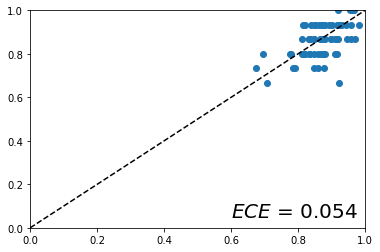

In [ ]:
# plotting the softmax outputs
binned_out = outputs.view(-1, 15, 794)
batch_accuracy = (binned_out.argmax(-1) == labels.view(-1, 15)).float().mean(-1)
batch_confidence = binned_out.max(-1)[0].mean(-1)
estimated_calibration_error = (batch_confidence - batch_accuracy).abs().mean()
plt.scatter(batch_confidence, batch_accuracy)
plt.plot([0, 1], [0, 1], linestyle='dashed', color='black')
plt.annotate(f"$ECE$ = {estimated_calibration_error:.3f}", (0.6, 0.05), fontsize=20)
plt.xlim(0,1)
plt.ylim(0,1)